# Exploration of Machine Learning Algorithms for Predicting Dissolved Organic Content in Lakes (Sentinel-2)

In [55]:
import matplotlib.font_manager as fm
import matplotlib as plt

available_fonts = sorted({f.name for f in fm.fontManager.ttflist})
plt.rcParams['font.family'] = 'Garamond'
plt.rcParams['font.size'] = 11.5

## Data Pre-processing

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import ee
import geemap
Map= geemap.Map()

### In-situ Measurements

In [57]:
ltm_file = pd.read_excel(r"C:\Users\aisha\OneDrive\Desktop\summer_2026_project_review\NSF_reserach\LTM_Data_2023_3_9.xlsx")

water_chemistry_cols = [
    'ANC_UEQ_L', 'CA_UEQ_L', 'CHL_A_UG_L', 'CL_UEQ_L', 'COLOR_APP_PTCO',
    'COLOR_TRU_PTCO', 'COND_US_CM', 'F_UEQ_L', 'K_UEQ_L',
    'MG_UEQ_L', 'NA_UEQ_L', 'NH4_UEQ_L', 'NO3_UEQ_L', 'N_TD_UEQ_L', 'PH_EQ',
    'PH_FLD', 'PH_LAB', 'PH_STVL', 'P_TL_UEQ_L', 'SECCHI_M', 'SIO2_MG_L',
    'SO4_UEQ_L', 'WTEMP_DEG_C', 'month', 'TIME_SMP', 'SAMPLE_TYPE'
]

ltm_file = ltm_file.drop(columns=water_chemistry_cols)
ltm_file = ltm_file[ltm_file['SAMPLE_LOCATION'] == 'EPI']
ltm_file = ltm_file.drop(columns=['SAMPLE_LOCATION'])
ltm_file = ltm_file[ltm_file['PROGRAM_ID'] == 'LTM_ALTM']
ltm_file = ltm_file.drop(columns=['PROGRAM_ID'])
ltm_file = ltm_file.dropna(subset=['SAMPLE_DEPTH'])
ltm_file['DOC_MG_L'] = ltm_file.groupby('SITE_ID')['DOC_MG_L'].transform(
    lambda x: x.fillna(x.mean())
) # for missing DOC values
ltm_file = ltm_file.sort_values(by='DATE_SMP', ascending=True)

ltm_file

,SITE_ID,DATE_SMP,WATERBODY_TYPE,SAMPLE_DEPTH,DOC_MG_L
16466,1A2-028,1992-06-08,Lake,0.0,6.0110
18694,1A1-102,1992-06-08,Lake,0.0,5.4140
31710,020188,1992-06-08,Lake,0.5,5.7600
23215,020197,1992-06-08,Lake,0.5,5.2010
20774,020138,1992-06-08,Lake,0.0,10.8910
...,...,...,...,...,...
3121,04253635,2021-09-27,Stream,0.0,9.9095
17747,1A1-017,2021-09-27,Lake,0.0,9.8247
3119,04253630,2021-09-27,Stream,0.0,8.7181
10439,1A1-111,2021-09-27,Lake,0.0,12.2881


In [58]:
print("ltm_file:", ltm_file.columns)


ltm_file: Index(['SITE_ID', 'DATE_SMP', 'WATERBODY_TYPE', 'SAMPLE_DEPTH', 'DOC_MG_L'], dtype='object')


In [59]:
ltm_file.isna().sum()

SITE_ID           0
DATE_SMP          0
WATERBODY_TYPE    0
SAMPLE_DEPTH      0
DOC_MG_L          0
dtype: int64

In [60]:
ltm_file['SITE_ID'].nunique()

59

In [61]:
site_info_file = pd.read_excel(r"C:\Users\aisha\OneDrive\Desktop\summer_2026_project_review\NSF_reserach\Site_Information_2022_8_1.xlsx")

selected_features = [
    'SITE_ID', 'PROGRAM_ID', 'SITE_NAME', 
    'LATDD', 'LONDD', 'LATDD_CENTROID', 'LONDD_CENTROID',
    'ECOREGION_IV',
    'ECONAME_IV',
    'LAKE_DEPTH_MAX', 'LAKE_DEPTH_MEAN',
    'LAKE_AREA_HA',
    'WSHD_AREA_HA', 'SITE_ELEV',
    'WSHD_ELEV_AVG',
    'WSHD_SLOPE_AVG'
]
#  'WSHD_ELEV_MIN', 'WSHD_ELEV_MAX'

site_info_file = site_info_file[selected_features]
site_info_file = site_info_file[site_info_file['PROGRAM_ID'] == 'LTM_ALTM']
site_info_file['LATDD_CENTROID'] = site_info_file['LATDD_CENTROID'].fillna(site_info_file['LATDD'])
site_info_file['LONDD_CENTROID'] = site_info_file['LONDD_CENTROID'].fillna(site_info_file['LONDD'])
site_info_file = site_info_file.drop(columns=['LATDD'])
site_info_file = site_info_file.drop(columns=['LONDD'])
# site_info_file = site_info_file.dropna(subset=['LAKE_DEPTH_MEAN'])
site_info_file = site_info_file.drop(columns=['PROGRAM_ID'])
for col in ['LAKE_DEPTH_MAX', 'LAKE_DEPTH_MEAN', 'LAKE_AREA_HA', 'WSHD_AREA_HA', 'WSHD_ELEV_AVG', 'WSHD_SLOPE_AVG']:
    site_info_file[col] = site_info_file.groupby('ECOREGION_IV')[col].transform(lambda x: x.fillna(x.median()))

site_info_file
# print(site_info_file.head(5))

,SITE_ID,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,ECOREGION_IV,ECONAME_IV,LAKE_DEPTH_MAX,LAKE_DEPTH_MEAN,LAKE_AREA_HA,WSHD_AREA_HA,SITE_ELEV,WSHD_ELEV_AVG,WSHD_SLOPE_AVG
2,1A1-052,Arbutus Pond,43.98787,-74.24151,58ad,Central Adirondacks,7.9,2.80,48.9,341.190,515.77,664.200,21.19000
3,050707,Avalanche Lake,44.13287,-73.96681,58j,Upper Montane/Alpine Zone,7.0,3.30,4.4,124.110,875.23,1094.150,64.44000
5,1A2-076,Barnes Lake,43.56611,-75.22694,58ab,Northern and Western Adirondack Foothills,10.1,4.50,2.9,62.145,394.92,408.715,8.81000
12,020059,Big Hope Pond,44.51369,-74.12683,58ad,Central Adirondacks,11.5,5.80,8.9,98.910,516.23,536.600,7.09000
14,1A1-103,Big Moose Lake,43.83221,-74.84646,58aa,Acid Sensitive Adirondacks,21.3,6.80,512.5,9656.010,557.24,649.220,13.47000
17,1A1-071,Black Pond,44.43786,-74.29351,58ad,Central Adirondacks,13.7,6.20,29.0,249.390,494.97,522.180,13.20000
18,030255,Black Pond Stream,44.43219,-74.29813,58ad,Central Adirondacks,6.4,3.10,4.0,59.760,495.09,517.290,6.88701
24,040874,Brook Trout Lake,43.60298,-74.66308,58aa,Acid Sensitive Adirondacks,23.2,8.40,28.7,159.750,724.03,774.360,22.21000
25,04253740,Bubb Lake Stream,43.78088,-74.85339,58aa,Acid Sensitive Adirondacks,10.1,3.45,24.7,343.710,537.70,617.430,7.58002
26,050669,Carry Pond,43.68229,-74.48867,58ad,Central Adirondacks,4.6,2.20,2.8,15.210,652.19,654.720,2.46000


In [62]:
print("site_info_file:", site_info_file.columns)


site_info_file: Index(['SITE_ID', 'SITE_NAME', 'LATDD_CENTROID', 'LONDD_CENTROID',
       'ECOREGION_IV', 'ECONAME_IV', 'LAKE_DEPTH_MAX', 'LAKE_DEPTH_MEAN',
       'LAKE_AREA_HA', 'WSHD_AREA_HA', 'SITE_ELEV', 'WSHD_ELEV_AVG',
       'WSHD_SLOPE_AVG'],
      dtype='object')


In [63]:
site_info_file.isna().sum()

SITE_ID            0
SITE_NAME          0
LATDD_CENTROID     0
LONDD_CENTROID     0
ECOREGION_IV       0
ECONAME_IV         0
LAKE_DEPTH_MAX     0
LAKE_DEPTH_MEAN    0
LAKE_AREA_HA       0
WSHD_AREA_HA       0
SITE_ELEV          0
WSHD_ELEV_AVG      0
WSHD_SLOPE_AVG     0
dtype: int64

In [64]:
site_info_file['SITE_ID'].nunique()

59

In [65]:
altm_df = pd.merge(ltm_file, site_info_file, on='SITE_ID', how='inner')
altm_df

,SITE_ID,DATE_SMP,WATERBODY_TYPE,SAMPLE_DEPTH,DOC_MG_L,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,ECOREGION_IV,ECONAME_IV,LAKE_DEPTH_MAX,LAKE_DEPTH_MEAN,LAKE_AREA_HA,WSHD_AREA_HA,SITE_ELEV,WSHD_ELEV_AVG,WSHD_SLOPE_AVG
0,1A2-028,1992-06-08,Lake,0.0,6.0110,Owen Pond,44.32156,-73.90114,58z,Adirondack High Peaks,9.4,3.70,7.6,1151.28,515.18,739.18,31.32000
1,1A1-102,1992-06-08,Lake,0.0,5.4140,Heart Lake,44.18229,-73.96920,58z,Adirondack High Peaks,16.8,5.10,10.7,67.86,659.88,694.91,19.46000
2,020188,1992-06-08,Lake,0.5,5.7600,Sunday Pond,44.34610,-74.30066,58ad,Central Adirondacks,11.0,5.40,4.0,29.34,494.95,495.26,0.33000
3,020197,1992-06-08,Lake,0.5,5.2010,Sochia Pond,44.35283,-74.29434,58ad,Central Adirondacks,5.5,3.10,1.6,38.43,494.95,496.06,1.24000
4,020138,1992-06-08,Lake,0.0,10.8910,East Copperas Pond,44.31395,-74.37624,58ad,Central Adirondacks,6.4,4.10,3.6,18.90,480.08,483.65,3.26000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16017,04253635,2021-09-27,Stream,0.0,9.9095,Squash Pond Stream,43.82170,-74.88246,58aa,Acid Sensitive Adirondacks,10.1,3.45,24.7,343.71,569.77,674.03,7.84262
16018,1A1-017,2021-09-27,Lake,0.0,9.8247,Constable Pond,43.83290,-74.79820,58aa,Acid Sensitive Adirondacks,4.0,2.10,20.6,941.85,579.65,641.00,13.29000
16019,04253630,2021-09-27,Stream,0.0,8.7181,Constable Pond Stream,43.82509,-74.83850,58aa,Acid Sensitive Adirondacks,10.1,3.45,24.7,343.71,561.05,641.95,7.67719
16020,1A1-111,2021-09-27,Lake,0.0,12.2881,Squash Pond,43.82649,-74.88699,58aa,Acid Sensitive Adirondacks,5.8,1.40,3.3,100.44,652.64,677.80,13.90000


In [66]:
altm_df['SITE_ID'].nunique()

59

In [67]:
altm_df['SITE_NAME'].unique()

array(['Owen Pond', 'Heart Lake', 'Sunday Pond', 'Sochia Pond',
       'East Copperas Pond', 'Grass Pond (3)', 'Little Hope Pond',
       'Little Echo Pond', 'Big Hope Pond', 'Middle Pond',
       'Little Clear Pond', 'Black Pond Stream', 'Lake Rondaxe',
       'Cascade Lake Stream', 'Barnes Lake', 'West Pond Stream',
       'Dart Lake', 'Queer Lake', 'Constable Pond Stream',
       'Big Moose Lake', 'Moss Lake', 'Bubb Lake Stream',
       'Squash Pond Stream', 'Windfall Pond Stream', 'Brook Trout Lake',
       'Indian Lake', 'Squaw Lake', 'North Lake',
       'South Lake (East Branch)', 'Lost Pond', 'Marcy Dam Pond',
       'Arbutus Pond', 'Lake Colden', 'Clear Pond', 'Nate Pond',
       'Avalanche Lake', 'Willis Lake', 'G Lake', 'Jockeybush Lake',
       'Limekiln Lake', 'Raquette Lake Reservoir', 'Woods Lake',
       'Sagamore Lake', 'Otter Lake Stream', 'Middle Settlement Lake',
       'Grass Pond', 'Middle Branch Lake', 'Willys Lake', 'Carry Pond',
       'Long Pond', 'Loon Hollow

In [68]:
altm_df.dtypes

SITE_ID                    object
DATE_SMP           datetime64[ns]
WATERBODY_TYPE             object
SAMPLE_DEPTH              float64
DOC_MG_L                  float64
SITE_NAME                  object
LATDD_CENTROID            float64
LONDD_CENTROID            float64
ECOREGION_IV               object
ECONAME_IV                 object
LAKE_DEPTH_MAX            float64
LAKE_DEPTH_MEAN           float64
LAKE_AREA_HA              float64
WSHD_AREA_HA              float64
SITE_ELEV                 float64
WSHD_ELEV_AVG             float64
WSHD_SLOPE_AVG            float64
dtype: object

In [ ]:
import pandas as pd

# Load the official 44 SITE_IDs
official_sites_df = pd.read_csv(r"C:\Users\aisha\OneDrive\Desktop\summer_2026_project_review\NSF_reserach\altm_44.csv")

# Make sure SITE_ID is clean and of string type
official_site_ids = official_sites_df['SITE_ID'].astype(str).unique()

# Filter altm_df to include only those SITE_IDs
altm_df = altm_df[altm_df['SITE_ID'].isin(official_site_ids)].copy()

# Check result
print(f"Original rows: {len(altm_df)}")
print(f"Filtered rows: {len(altm_df)}")
print(f"Unique SITE_IDs kept: {altm_df['SITE_ID'].nunique()}")


Original rows: 12143
Filtered rows: 12143
Unique SITE_IDs kept: 44


In [70]:
altm_df

,SITE_ID,DATE_SMP,WATERBODY_TYPE,SAMPLE_DEPTH,DOC_MG_L,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,ECOREGION_IV,ECONAME_IV,LAKE_DEPTH_MAX,LAKE_DEPTH_MEAN,LAKE_AREA_HA,WSHD_AREA_HA,SITE_ELEV,WSHD_ELEV_AVG,WSHD_SLOPE_AVG
0,1A2-028,1992-06-08,Lake,0.0,6.0110,Owen Pond,44.32156,-73.90114,58z,Adirondack High Peaks,9.4,3.7,7.6,1151.28,515.18,739.18,31.32
1,1A1-102,1992-06-08,Lake,0.0,5.4140,Heart Lake,44.18229,-73.96920,58z,Adirondack High Peaks,16.8,5.1,10.7,67.86,659.88,694.91,19.46
2,020188,1992-06-08,Lake,0.5,5.7600,Sunday Pond,44.34610,-74.30066,58ad,Central Adirondacks,11.0,5.4,4.0,29.34,494.95,495.26,0.33
3,020197,1992-06-08,Lake,0.5,5.2010,Sochia Pond,44.35283,-74.29434,58ad,Central Adirondacks,5.5,3.1,1.6,38.43,494.95,496.06,1.24
4,020138,1992-06-08,Lake,0.0,10.8910,East Copperas Pond,44.31395,-74.37624,58ad,Central Adirondacks,6.4,4.1,3.6,18.90,480.08,483.65,3.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16013,040874,2021-09-22,Lake,0.0,4.7538,Brook Trout Lake,43.60298,-74.66308,58aa,Acid Sensitive Adirondacks,23.2,8.4,28.7,159.75,724.03,774.36,22.21
16014,030172,2021-09-23,Lake,0.5,6.9832,Little Clear Pond,44.66237,-74.50042,58ab,Northern and Western Adirondack Foothills,14.0,5.5,1.9,79.56,381.70,408.40,8.81
16016,020059,2021-09-23,Lake,0.5,8.4643,Big Hope Pond,44.51369,-74.12683,58ad,Central Adirondacks,11.5,5.8,8.9,98.91,516.23,536.60,7.09
16018,1A1-017,2021-09-27,Lake,0.0,9.8247,Constable Pond,43.83290,-74.79820,58aa,Acid Sensitive Adirondacks,4.0,2.1,20.6,941.85,579.65,641.00,13.29


In [71]:
altm_df['SITE_ID'].nunique()

44

In [72]:
# Display unique SITE_NAME and SITE_ID pairs
site_info = altm_df[['SITE_NAME', 'SITE_ID']].drop_duplicates().sort_values(by='SITE_NAME')
print(site_info.to_string(index=False))


              SITE_NAME SITE_ID
           Arbutus Pond 1A1-052
         Avalanche Lake  050707
            Barnes Lake 1A2-076
          Big Hope Pond  020059
         Big Moose Lake 1A1-103
             Black Pond 1A1-071
       Brook Trout Lake  040874
             Carry Pond  050669
           Cascade Lake 1A1-105
             Clear Pond 1A2-077
         Constable Pond 1A1-017
              Dart Lake 1A1-106
     East Copperas Pond  020138
                 G Lake  070859
             Grass Pond 1A3-048
         Grass Pond (3)  030171
             Heart Lake 1A1-102
            Indian Lake  040852
        Jockeybush Lake 1A2-066
            Lake Colden  050706
           Lake Rondaxe 1A1-110
          Limekiln Lake  040826
      Little Clear Pond  030172
       Little Echo Pond 1A1-107
       Little Hope Pond  020058
      Little Simon Pond  060182
       Loon Hollow Pond  040186
              Lost Pond  040887
     Middle Branch Lake  040707
            Middle Pond 1A1-029
 Middle 

### Get Satellite Data

In [73]:
ee.Authenticate()

True

In [74]:
# import ee
# import pandas as pd

# ee.Initialize()

# # Load lake polygons
# altm_lakes = ee.FeatureCollection("projects/ee-aishamalik1021/assets/altm_lakes")

# # Sentinel-2 bands and standardized names
# S2_BANDS = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B8', 'B8A', 'B11']
# STD_NAMES = ['Aerosols', 'Blue', 'Green', 'Red', 'RedEdge1', 'RedEdge2', 'RedEdge4', 'NIR', 'SWIR1']

# # -------------------------------
# # Cloud Masking Function for Sentinel-2 SR
# # -------------------------------
# def maskS2clouds(image):
#     scl = image.select('SCL')
#     cloud_mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    
#     # Return masked image, ensure properties like time are preserved
#     return image.updateMask(cloud_mask).copyProperties(image, image.propertyNames())

# # -------------------------------
# # Function to extract reflectance per image
# # -------------------------------
# def reflectance(img, geom):
#     reducer = ee.Reducer.mean()
#     stats = img.reduceRegion(reducer=reducer, geometry=geom, scale=20, bestEffort=True)
#     return img.set({
#         'DATE_SMP': img.date().format('YYYY-MM-dd'),
#         'reflectance': stats
#     })

# # -------------------------------
# # Iterate through lakes
# # -------------------------------
# site_ids = altm_df['SITE_ID'].unique().tolist()
# dfs = []

# for site_id in site_ids:
#     lake_feat = altm_lakes.filter(ee.Filter.eq('SITE_ID', site_id)).first()
#     geom = lake_feat.geometry().buffer(-5)
#     SITE_NAME = site_id

#     # Load Sentinel-2 SR collection
#     s2 = (
#         ee.ImageCollection('COPERNICUS/S2_SR')
#         .filterBounds(geom)
#         .filterDate('2017-01-01', '2023-12-31')
#         .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
#         .filter(ee.Filter.notNull(['system:time_start']))  # <-- filter out problematic images
#         .map(maskS2clouds)
#         .select(S2_BANDS)
#         .map(lambda img: img.divide(10000).copyProperties(img, img.propertyNames()))
#     )

#     # Extract reflectance
#     map_reflectance = s2.map(lambda img: reflectance(img, geom))

#     list_reflectance = map_reflectance.reduceColumns(
#         ee.Reducer.toList(2), ['DATE_SMP', 'reflectance']
#     ).values().get(0)

#     df_reflectance = pd.DataFrame(list_reflectance.getInfo(), columns=['DATE_SMP', 'reflectance'])
#     df_reflectance['DATE_SMP'] = pd.to_datetime(df_reflectance['DATE_SMP']).dt.date

#     # Expand reflectance dictionary and filter
#     reflectance_df = df_reflectance['reflectance'].apply(pd.Series)
#     reflectance_df = reflectance_df[[band for band in S2_BANDS if band in reflectance_df.columns]]

#     # Rename to standard names
#     band_rename = dict(zip(S2_BANDS, STD_NAMES))
#     reflectance_df.rename(columns=band_rename, inplace=True)

#     # Combine with metadata
#     df_reflectance = pd.concat([df_reflectance[['DATE_SMP']], reflectance_df], axis=1)
#     df_reflectance['SITE_ID'] = SITE_NAME

#     dfs.append(df_reflectance)

# # Combine all lakes into one DataFrame
# df_all_lakes = pd.concat(dfs, ignore_index=True)
# df_all_lakes.sort_values(by='DATE_SMP', inplace=True)
# df_all_lakes.dropna(inplace=True)

In [75]:
df_all_lakes = pd.read_csv(r"C:\Users\aisha\OneDrive\Desktop\summer_2026_project_review\NSF_reserach\S2_altm_sr.csv")
df_all_lakes

,DATE_SMP,Aerosols,Blue,Green,Red,RedEdge1,RedEdge2,RedEdge4,NIR,SWIR1,SITE_ID
0,2018-03-25,1.118066,1.286355,1.221484,1.172703,1.183795,1.115747,1.022644,0.942983,0.144272,1A2-076
1,2018-03-25,0.195613,0.162532,0.166891,0.164868,0.179348,0.194063,0.196874,0.198558,0.121459,040186
2,2018-05-16,0.113372,0.114643,0.113733,0.111975,0.115384,0.119139,0.121473,0.122531,0.119790,1A2-028
3,2018-05-16,0.118647,0.119063,0.118200,0.114787,0.119866,0.127787,0.131443,0.132190,0.125553,1A1-071
4,2018-05-16,0.123079,0.117393,0.114766,0.111416,0.116956,0.122380,0.125096,0.126441,0.125538,030171
...,...,...,...,...,...,...,...,...,...,...,...
2221,2023-12-21,0.649993,0.694182,0.682757,0.685704,0.698711,0.682080,0.673052,0.634337,0.155280,040852
2222,2023-12-21,0.430139,0.448523,0.438974,0.435007,0.441991,0.429329,0.408463,0.385831,0.130327,040850
2223,2023-12-21,0.544151,0.618990,0.618123,0.622282,0.633262,0.625842,0.621376,0.579387,0.174069,040887
2224,2023-12-21,0.461459,0.485654,0.476076,0.468277,0.471045,0.455439,0.414491,0.381937,0.131823,1A1-052


In [76]:
# output_path = r"C:\Users\aisha\OneDrive\Desktop\summer_2026_project_review\NSF_reserach\S2_altm_sr.csv"
# df_all_lakes.to_csv(output_path, index=False)

In [77]:
df_all_lakes['SITE_ID'].nunique()

44

In [78]:
altm_df['SITE_ID'].nunique()

44

In [79]:
# Make sure DATE_SMP is a datetime.date object in both DataFrames
df_all_lakes['DATE_SMP'] = pd.to_datetime(df_all_lakes['DATE_SMP']).dt.date
altm_df['DATE_SMP'] = pd.to_datetime(altm_df['DATE_SMP']).dt.date

# Merge on SITE_ID and DATE_SMP
atlm_sr = pd.merge(
    altm_df,                # Left: master data with DOC
    df_all_lakes,           # Right: satellite reflectance data
    on=['SITE_ID', 'DATE_SMP'],
    how='inner'             # Only keep matching records
)

# Preview result
atlm_sr

,SITE_ID,DATE_SMP,WATERBODY_TYPE,SAMPLE_DEPTH,DOC_MG_L,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,ECOREGION_IV,ECONAME_IV,...,WSHD_SLOPE_AVG,Aerosols,Blue,Green,Red,RedEdge1,RedEdge2,RedEdge4,NIR,SWIR1
0,040186,2019-02-28,Lake,0.5,8.126200,Loon Hollow Pond,43.96292,-75.04305,58aa,Acid Sensitive Adirondacks,...,10.90,0.922903,1.004681,0.946073,0.939899,0.950335,0.932764,0.953949,0.868924,0.132914
1,040186,2019-04-04,Lake,0.5,8.023800,Loon Hollow Pond,43.96292,-75.04305,58aa,Acid Sensitive Adirondacks,...,10.90,0.682019,0.766678,0.732747,0.735804,0.748210,0.738415,0.733389,0.678488,0.033180
2,1A1-102,2019-09-18,Lake,0.0,2.770000,Heart Lake,44.18229,-73.96920,58z,Adirondack High Peaks,...,19.46,0.105323,0.112293,0.114409,0.106182,0.106905,0.109839,0.112822,0.112761,0.109398
3,1A1-102,2019-09-18,Lake,0.0,2.770000,Heart Lake,44.18229,-73.96920,58z,Adirondack High Peaks,...,19.46,0.106157,0.112666,0.114472,0.106121,0.106821,0.109274,0.112008,0.111984,0.109307
4,1A1-052,2019-09-18,Lake,0.0,5.397100,Arbutus Pond,43.98787,-74.24151,58ad,Central Adirondacks,...,21.19,0.107361,0.108963,0.109603,0.106967,0.111843,0.118024,0.120332,0.121441,0.113005
5,1A2-077,2019-09-18,Lake,0.0,4.099900,Clear Pond,43.99719,-73.82435,58z,Adirondack High Peaks,...,17.89,0.105514,0.110274,0.109263,0.105468,0.108596,0.116152,0.118726,0.118267,0.109850
6,020138,2020-05-20,Lake,0.0,12.007031,East Copperas Pond,44.31395,-74.37624,58ad,Central Adirondacks,...,3.26,0.117460,0.115015,0.119793,0.111875,0.113185,0.115032,0.117425,0.117654,0.116782
7,1A3-048,2020-06-04,Lake,0.0,4.499849,Grass Pond,43.69207,-75.06172,58aa,Acid Sensitive Adirondacks,...,13.47,0.020804,0.020945,0.019961,0.017614,0.023080,0.024463,0.028044,0.028394,0.023331
8,1A1-110,2020-06-04,Lake,0.0,4.920053,Lake Rondaxe,43.76697,-74.90136,58aa,Acid Sensitive Adirondacks,...,14.10,0.034577,0.034426,0.036918,0.031650,0.046453,0.071064,0.077573,0.083413,0.055776
9,030172,2021-02-04,Lake,0.5,7.474600,Little Clear Pond,44.66237,-74.50042,58ab,Northern and Western Adirondack Foothills,...,8.81,0.940383,1.046485,1.034209,1.038483,1.074921,1.043706,1.034512,0.973219,0.248424


In [80]:
atlm_sr['SITE_ID'].nunique()

10

In [81]:
import pandas as pd
from datetime import timedelta

# Ensure DATE_SMP columns are datetime
altm_df['DATE_SMP'] = pd.to_datetime(altm_df['DATE_SMP'])
df_all_lakes['DATE_SMP'] = pd.to_datetime(df_all_lakes['DATE_SMP'])

# Expand altm_df by ±3 days and keep original sample date
expanded_records = []

for _, row in altm_df.iterrows():
    original_date = row['DATE_SMP']
    for delta in range(-3, 4):  # from -3 to +3 days
        new_row = row.copy()
        new_row['DATE_SMP'] = original_date + timedelta(days=delta)
        new_row['ORIG_DATE'] = original_date  # store original sample date
        expanded_records.append(new_row)

altm_df_expanded = pd.DataFrame(expanded_records)

# Merge expanded altm_df with satellite data on SITE_ID and DATE_SMP
altm_sr = pd.merge(
    altm_df_expanded,
    df_all_lakes,
    on=['SITE_ID', 'DATE_SMP'],
    how='inner'
)

# Calculate absolute difference between satellite date and original sample date
altm_sr['DATE_DIFF'] = (altm_sr['ORIG_DATE'] - altm_sr['DATE_SMP']).abs().dt.days

# Keep the closest satellite record for each original sample (SITE_ID + ORIG_DATE)
altm_sr = altm_sr.sort_values(by=['SITE_ID', 'ORIG_DATE', 'DATE_DIFF']) \
                     .drop_duplicates(subset=['SITE_ID', 'ORIG_DATE'], keep='first')

# Optionally drop helper column
altm_sr = altm_sr.drop(columns=['DATE_DIFF', 'ORIG_DATE', 'SAMPLE_DEPTH'])

# Drop helper column
altm_sr

,SITE_ID,DATE_SMP,WATERBODY_TYPE,DOC_MG_L,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,ECOREGION_IV,ECONAME_IV,LAKE_DEPTH_MAX,...,WSHD_SLOPE_AVG,Aerosols,Blue,Green,Red,RedEdge1,RedEdge2,RedEdge4,NIR,SWIR1
51,020058,2020-07-24,Lake,10.425714,Little Hope Pond,44.51731,-74.12629,58ad,Central Adirondacks,6.2,...,9.55,0.112627,0.110346,0.109186,0.106443,0.112203,0.130128,0.135595,0.140248,0.124820
50,020059,2020-07-24,Lake,8.765695,Big Hope Pond,44.51369,-74.12683,58ad,Central Adirondacks,11.5,...,7.09,0.111148,0.109387,0.106402,0.105156,0.106834,0.111074,0.112574,0.114620,0.109452
67,020059,2021-02-04,Lake,9.181600,Big Hope Pond,44.51369,-74.12683,58ad,Central Adirondacks,11.5,...,7.09,0.940535,1.015550,1.000041,1.000992,1.029002,1.001271,0.987351,0.930912,0.206706
89,020059,2021-04-10,Lake,7.907400,Big Hope Pond,44.51369,-74.12683,58ad,Central Adirondacks,11.5,...,7.09,0.104877,0.105128,0.102495,0.103176,0.104468,0.106103,0.107686,0.109069,0.110848
21,020138,2019-09-18,Lake,10.955500,East Copperas Pond,44.31395,-74.37624,58ad,Central Adirondacks,6.4,...,3.26,0.109032,0.115895,0.121506,0.111713,0.112091,0.114683,0.117701,0.117964,0.111305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,1A2-078,2020-05-30,Lake,3.093634,Otter Lake,43.18837,-74.49935,58aa,Acid Sensitive Adirondacks,4.0,...,15.85,0.055019,0.043159,0.046903,0.040477,0.052890,0.080617,0.090045,0.094900,0.072595
69,1A2-078,2021-04-05,Lake,3.572900,Otter Lake,43.18837,-74.49935,58aa,Acid Sensitive Adirondacks,4.0,...,15.85,0.310566,0.333949,0.333220,0.317968,0.313904,0.291901,0.252802,0.233532,0.134221
40,1A3-001,2020-07-04,Lake,5.467659,Nate Pond,43.85752,-74.09038,58ad,Central Adirondacks,6.4,...,12.31,0.132210,0.134337,0.134735,0.132300,0.138607,0.150749,0.154699,0.159313,0.145282
10,1A3-048,2019-09-18,Lake,5.176900,Grass Pond,43.69207,-75.06172,58aa,Acid Sensitive Adirondacks,5.2,...,13.47,0.109209,0.110214,0.112110,0.111309,0.120315,0.125315,0.131283,0.131010,0.120528


In [82]:
# Step 1: Make a copy to preserve original
df = altm_sr.copy()

# Step 2: Define the IQR bounds
Q1 = df['DOC_MG_L'].quantile(0.25)
Q3 = df['DOC_MG_L'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Filter out outliers
altm_sr = df[(df['DOC_MG_L'] >= lower_bound) & (df['DOC_MG_L'] <= upper_bound)]

# Step 4 (Optional): Show how many were removed
print(f"Removed {len(df) - len(altm_sr)} outliers out of {len(df)} total rows.")

# df_filtered now contains your cleaned dataset


Removed 6 outliers out of 75 total rows.


In [83]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# spectral_bands = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']

# for col in spectral_bands:
#     plt.figure(figsize=(6, 3))
#     sns.histplot(altm_sr[col], kde=True)
#     plt.title(f"Histogram of {col} (with outliers)")
#     plt.tight_layout()
#     plt.show()

In [84]:
# import matplotlib.pyplot as plt

# plt.hist(merged_df['DATE_DIFF'], bins=7, edgecolor='black')  # bins 0 to 6 days
# plt.title('Distribution of Date Differences (days)')
# plt.xlabel('Days difference between sample date and satellite date')
# plt.ylabel('Number of samples')
# plt.show()


### Dataset - Feature Engineering

In [85]:
altm_sr['year'] = altm_sr['DATE_SMP'].dt.year
altm_sr['month'] = altm_sr['DATE_SMP'].dt.month
altm_sr['dayofyear'] = altm_sr['DATE_SMP'].dt.dayofyear

# | Feature                 | Why Drop                                                                         |
# | ----------------------- | -------------------------------------------------------------------------------- |
# | `WATERBODY_TYPE_Stream` | Binary/categorical type — may differ in meaning across datasets or regions       |
# | `ECONAME_IV_*`          | Ecoregion labels — only defined for a local area (e.g., Adirondacks), not global |


altm_sr_processed = altm_sr.drop(columns=['DATE_SMP', 'ECOREGION_IV', 'ECONAME_IV', 'WATERBODY_TYPE'])  # drop if not needed anymore
# altm_sr_processed = pd.get_dummies(altm_sr_processed, columns=['WATERBODY_TYPE', 'ECONAME_IV'], drop_first=True)
altm_sr_processed

,SITE_ID,DOC_MG_L,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,LAKE_DEPTH_MAX,LAKE_DEPTH_MEAN,LAKE_AREA_HA,WSHD_AREA_HA,SITE_ELEV,...,Green,Red,RedEdge1,RedEdge2,RedEdge4,NIR,SWIR1,year,month,dayofyear
51,020058,10.425714,Little Hope Pond,44.51731,-74.12629,6.2,3.50,2.8,59.76,516.97,...,0.109186,0.106443,0.112203,0.130128,0.135595,0.140248,0.124820,2020,7,206
50,020059,8.765695,Big Hope Pond,44.51369,-74.12683,11.5,5.80,8.9,98.91,516.23,...,0.106402,0.105156,0.106834,0.111074,0.112574,0.114620,0.109452,2020,7,206
67,020059,9.181600,Big Hope Pond,44.51369,-74.12683,11.5,5.80,8.9,98.91,516.23,...,1.000041,1.000992,1.029002,1.001271,0.987351,0.930912,0.206706,2021,2,35
89,020059,7.907400,Big Hope Pond,44.51369,-74.12683,11.5,5.80,8.9,98.91,516.23,...,0.102495,0.103176,0.104468,0.106103,0.107686,0.109069,0.110848,2021,4,100
21,020138,10.955500,East Copperas Pond,44.31395,-74.37624,6.4,4.10,3.6,18.90,480.08,...,0.121506,0.111713,0.112091,0.114683,0.117701,0.117964,0.111305,2019,9,261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,1A2-078,3.093634,Otter Lake,43.18837,-74.49935,4.0,3.45,16.2,337.77,504.90,...,0.046903,0.040477,0.052890,0.080617,0.090045,0.094900,0.072595,2020,5,151
69,1A2-078,3.572900,Otter Lake,43.18837,-74.49935,4.0,3.45,16.2,337.77,504.90,...,0.333220,0.317968,0.313904,0.291901,0.252802,0.233532,0.134221,2021,4,95
40,1A3-001,5.467659,Nate Pond,43.85752,-74.09038,6.4,2.30,8.3,100.35,612.47,...,0.134735,0.132300,0.138607,0.150749,0.154699,0.159313,0.145282,2020,7,186
10,1A3-048,5.176900,Grass Pond,43.69207,-75.06172,5.2,1.50,5.3,343.71,548.67,...,0.112110,0.111309,0.120315,0.125315,0.131283,0.131010,0.120528,2019,9,261


In [86]:
# | Index          | Formula                           | What it Captures           |
# | -------------- | --------------------------------- | -------------------------- |
# | NDVI           | (nir - red) / (nir + red)         | Vegetation / algal content |
# | NDWI           | (green - nir) / (green + nir)     | Water presence             |
# | MNDWI          | (green - swir1) / (green + swir1) | Improved water clarity     |
# | Red/NIR Ratio  | red / nir                         | CDOM and turbidity         |
# | SWIR/NIR Ratio | swir1 / nir                       | Organic matter & moisture  |


In [ ]:
import numpy as np

# Avoid division by zero errors
epsilon = 1e-6

# Create engineered band-based features
altm_sr_processed['blue_green_ratio'] = altm_sr_processed['Blue'] / (altm_sr_processed['Green'] + epsilon)
altm_sr_processed['red_nir_ratio'] = altm_sr_processed['Red'] / (altm_sr_processed['NIR'] + epsilon)

altm_sr_processed['NDWI'] = (altm_sr_processed['Green'] - altm_sr_processed['NIR']) / (
    altm_sr_processed['Green'] + altm_sr_processed['NIR'] + epsilon)

altm_sr_processed['MNDWI'] = (altm_sr_processed['Green'] - altm_sr_processed['SWIR1']) / (
    altm_sr_processed['Green'] + altm_sr_processed['SWIR1'] + epsilon)

altm_sr_processed['NDTI'] = (altm_sr_processed['Red'] - altm_sr_processed['Green']) / (
    altm_sr_processed['Red'] + altm_sr_processed['Green'] + epsilon)

altm_sr_processed['NDVI'] = (altm_sr_processed['NIR'] - altm_sr_processed['Red']) / (
    altm_sr_processed['NIR'] + altm_sr_processed['Red'] + epsilon)

altm_sr_processed['red_nir_ratio'] = altm_sr_processed['Red'] / (
    altm_sr_processed['NIR'] + epsilon)

altm_sr_processed['swir_nir_ratio'] = altm_sr_processed['SWIR1'] / (
    altm_sr_processed['NIR'] + epsilon)

# ---------- CDOM_proxy

# Safely compute CDOM proxy
safe_blue = altm_sr_processed['Blue'].clip(lower=epsilon)  # replace zeros or negative with epsilon
altm_sr_processed['CDOM_proxy'] = np.log(1 / safe_blue)

# Optional: Clip extreme values on ratios to reduce outlier influence
for col in ['blue_green_ratio', 'red_nir_ratio', 'NDWI', 'MNDWI', 'NDTI', 'NDVI', 'swir_nir_ratio']:
    lower = altm_sr_processed[col].quantile(0.01)  # 1st percentile
    upper = altm_sr_processed[col].quantile(0.99)  # 99th percentile
    altm_sr_processed[col] = altm_sr_processed[col].clip(lower=lower, upper=upper)

# Check for any NaNs or infinite values
nan_count = altm_sr_processed['CDOM_proxy'].isna().sum()
inf_count = np.isinf(altm_sr_processed['CDOM_proxy']).sum()
print(f"NaNs: {nan_count}, Infs: {inf_count}")

# Optional: Fill NaNs or infinite values if any remain
altm_sr_processed['CDOM_proxy'].replace([np.inf, -np.inf], np.nan, inplace=True)
altm_sr_processed['CDOM_proxy'].fillna(altm_sr_processed['CDOM_proxy'].median(), inplace=True)



NaNs: 0, Infs: 0


In [88]:
# | Feature                      | Reason to Keep                                     |
# | ---------------------------- | -------------------------------------------------- |
# | `LAKE_DEPTH_MAX`             | Bathymetric data, globally measurable              |
# | `LAKE_AREA_HA`               | Surface area — from satellite or maps              |
# | `WSHD_AREA_HA`               | Watershed area — GIS derivable                     |
# | `SITE_ELEV`                  | Elevation — globally known (e.g., SRTM)            |
# | `WSHD_ELEV_AVG`              | Avg watershed elevation — globally derivable       |
# | `WSHD_SLOPE_AVG`             | Avg slope — DEMs can provide this                  |
# | `blue`                       | Likely remote sensing band — global via satellites |
# | `year`, `month`, `dayofyear` | Time info — universal                              |

altm_sr_processed = altm_sr_processed.rename(columns={'Blue': 'blue'})
altm_sr_processed = altm_sr_processed.drop(columns=['Red', 'Green', 'SWIR1', 'NIR', 'RedEdge1', 'RedEdge2', 'RedEdge4', 'Aerosols', 'LAKE_DEPTH_MEAN', 'NDVI', 'red_nir_ratio'])

In [89]:
from sklearn.preprocessing import StandardScaler

# Copy original dataframe
altm_sr_processed = altm_sr_processed.copy()

# Features to scale
features_to_scale = [
    'LAKE_DEPTH_MAX', 'LAKE_AREA_HA', 'WSHD_AREA_HA',
    'SITE_ELEV', 'WSHD_ELEV_AVG', 'WSHD_SLOPE_AVG',
    'blue', 'blue_green_ratio', 'NDWI', 'MNDWI', 'CDOM_proxy', 'NDTI', 'swir_nir_ratio',
    'year', 'month', 'dayofyear'
]

# Initialize and apply scaler
scaler = StandardScaler()
altm_sr_processed[features_to_scale] = scaler.fit_transform(altm_sr_processed[features_to_scale])


In [90]:
altm_sr_processed.dtypes

SITE_ID              object
DOC_MG_L            float64
SITE_NAME            object
LATDD_CENTROID      float64
LONDD_CENTROID      float64
LAKE_DEPTH_MAX      float64
LAKE_AREA_HA        float64
WSHD_AREA_HA        float64
SITE_ELEV           float64
WSHD_ELEV_AVG       float64
WSHD_SLOPE_AVG      float64
blue                float64
year                float64
month               float64
dayofyear           float64
blue_green_ratio    float64
NDWI                float64
MNDWI               float64
NDTI                float64
swir_nir_ratio      float64
CDOM_proxy          float64
dtype: object

In [91]:
# Coliniarity

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_numeric = altm_sr_processed.select_dtypes(include='number').drop(columns=['DOC_MG_L'])

vif_data = pd.DataFrame()
vif_data["feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i)
                   for i in range(len(X_numeric.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))


             feature           VIF
0     LATDD_CENTROID  13393.807963
1     LONDD_CENTROID  13393.636134
11         dayofyear    222.384110
14             MNDWI    202.455862
10             month    189.327936
16    swir_nir_ratio     92.109829
13              NDWI     75.822178
17        CDOM_proxy     29.715086
8               blue     18.980183
6      WSHD_ELEV_AVG     11.848628
5          SITE_ELEV      9.155006
15              NDTI      8.560919
9               year      7.612606
7     WSHD_SLOPE_AVG      4.121651
12  blue_green_ratio      2.557683
4       WSHD_AREA_HA      2.406485
3       LAKE_AREA_HA      1.929929
2     LAKE_DEPTH_MAX      1.640382


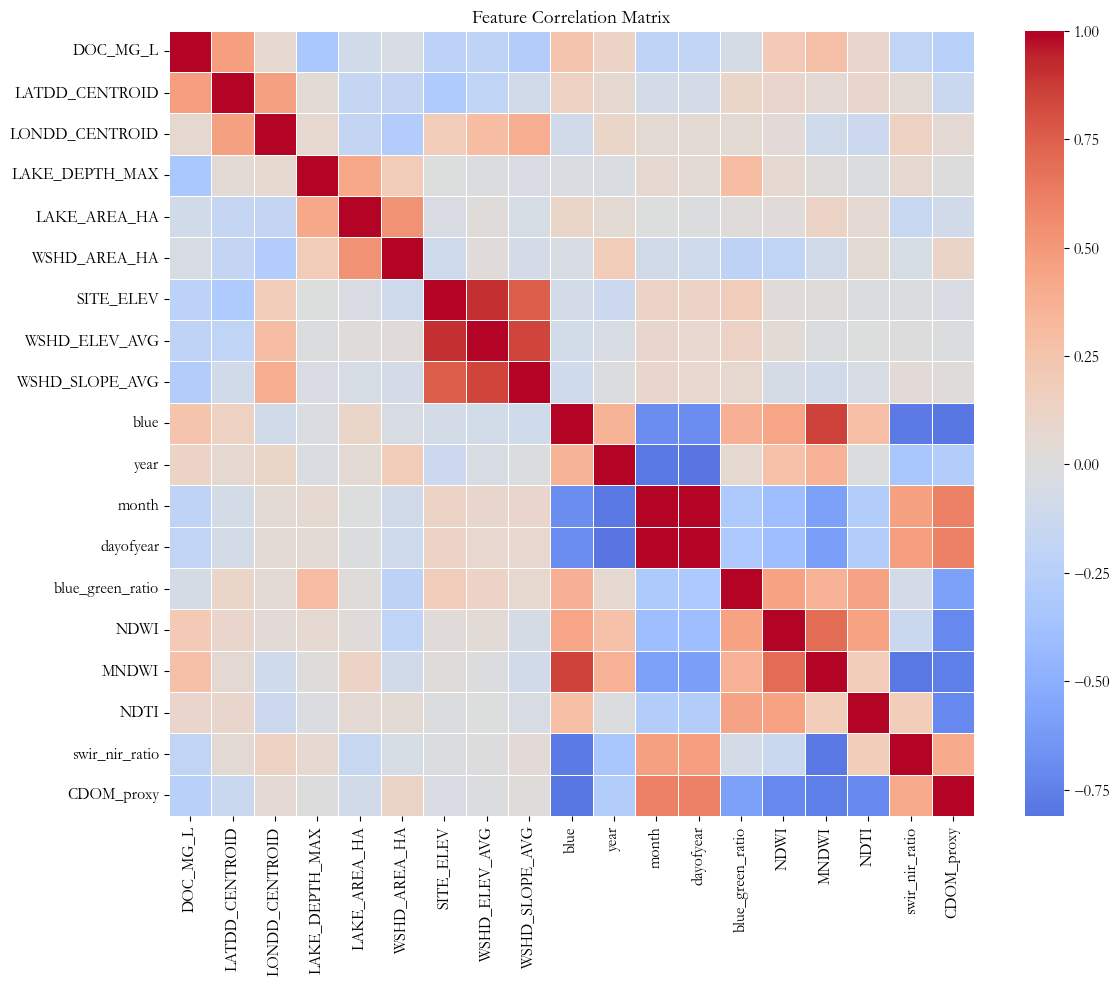

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only include numeric columns
corr_matrix = altm_sr_processed.select_dtypes(include='number').corr()

# Plot a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [93]:
# Get absolute correlations
abs_corr = corr_matrix.abs()

# Mask the diagonal and lower triangle
upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))

# Find pairs with correlation above threshold (e.g., 0.9)
high_corr = [(col, idx, upper.loc[idx, col])
             for col in upper.columns
             for idx in upper.index
             if pd.notnull(upper.loc[idx, col]) and abs(upper.loc[idx, col]) > 0.9]

# Display
for a, b, val in high_corr:
    print(f"{a} ↔ {b} = {val:.3f}")


WSHD_ELEV_AVG ↔ SITE_ELEV = 0.903
dayofyear ↔ month = 0.996


In [94]:
altm_sr_processed

,SITE_ID,DOC_MG_L,SITE_NAME,LATDD_CENTROID,LONDD_CENTROID,LAKE_DEPTH_MAX,LAKE_AREA_HA,WSHD_AREA_HA,SITE_ELEV,WSHD_ELEV_AVG,...,blue,year,month,dayofyear,blue_green_ratio,NDWI,MNDWI,NDTI,swir_nir_ratio,CDOM_proxy
51,020058,10.425714,Little Hope Pond,44.51731,-74.12629,-0.849122,-0.473546,-0.433112,-0.577463,-0.655943,...,-0.401233,0.038097,0.214515,0.335421,0.460809,-0.322404,-0.569049,0.345579,0.548865,0.113196
50,020059,8.765695,Big Hope Pond,44.51369,-74.12683,-0.084850,-0.404814,-0.422023,-0.584935,-0.719694,...,-0.404637,0.038097,0.214515,0.335421,0.792360,0.242270,-0.377395,0.447531,0.807499,0.121017
67,020059,9.181600,Big Hope Pond,44.51369,-74.12683,-0.084850,-0.404814,-0.422023,-0.584935,-0.719694,...,2.811388,1.352442,-1.785695,-1.807315,0.553852,0.714067,2.065754,0.542491,-2.112185,-1.875380
89,020059,7.907400,Big Hope Pond,44.51369,-74.12683,-0.084850,-0.404814,-0.422023,-0.584935,-0.719694,...,-0.419754,1.352442,-0.985611,-0.992825,0.747348,0.281730,-0.468441,0.584824,1.052093,0.156602
21,020138,10.955500,East Copperas Pond,44.31395,-74.37624,-0.820282,-0.464532,-0.444685,-0.949968,-1.049668,...,-0.381541,-1.276248,1.014599,1.024605,-0.619720,0.578229,-0.166581,-0.091136,0.762212,0.069241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,1A2-078,3.093634,Otter Lake,43.18837,-74.49935,-1.166368,-0.322561,-0.354369,-0.699342,-0.492981,...,-0.639683,0.038097,-0.585569,-0.353763,-1.260006,-1.705434,-1.108160,-0.561966,0.050750,0.954225
69,1A2-078,3.572900,Otter Lake,43.18837,-74.49935,-1.166368,-0.322561,-0.354369,-0.699342,-0.492981,...,0.392345,1.352442,-0.985611,-1.055478,0.300384,1.619704,1.222823,0.185888,-0.707067,-0.878927
40,1A3-001,5.467659,Nate Pond,43.85752,-74.09038,-0.820282,-0.411575,-0.421615,0.386870,-0.057067,...,-0.316087,0.038097,0.214515,0.084809,0.202586,-0.057701,-0.463017,0.399319,0.636261,-0.063062
10,1A3-048,5.176900,Grass Pond,43.69207,-75.06172,-0.993325,-0.445377,-0.352686,-0.257365,-0.080436,...,-0.401701,-1.276248,1.014599,1.024605,-0.062914,-0.019941,-0.457637,0.481902,0.668358,0.114268


In [95]:
altm_sr_processed.isna().sum()

SITE_ID             0
DOC_MG_L            0
SITE_NAME           0
LATDD_CENTROID      0
LONDD_CENTROID      0
LAKE_DEPTH_MAX      0
LAKE_AREA_HA        0
WSHD_AREA_HA        0
SITE_ELEV           0
WSHD_ELEV_AVG       0
WSHD_SLOPE_AVG      0
blue                0
year                0
month               0
dayofyear           0
blue_green_ratio    0
NDWI                0
MNDWI               0
NDTI                0
swir_nir_ratio      0
CDOM_proxy          0
dtype: int64

## Random Forest Model

Feature order used for training/testing:
['LAKE_DEPTH_MAX', 'LAKE_AREA_HA', 'WSHD_AREA_HA', 'SITE_ELEV', 'WSHD_ELEV_AVG', 'WSHD_SLOPE_AVG', 'blue', 'year', 'month', 'dayofyear', 'blue_green_ratio', 'NDWI', 'MNDWI', 'NDTI', 'swir_nir_ratio', 'CDOM_proxy']
📊 RMSE: 2.275
📈 R² Score: 0.717


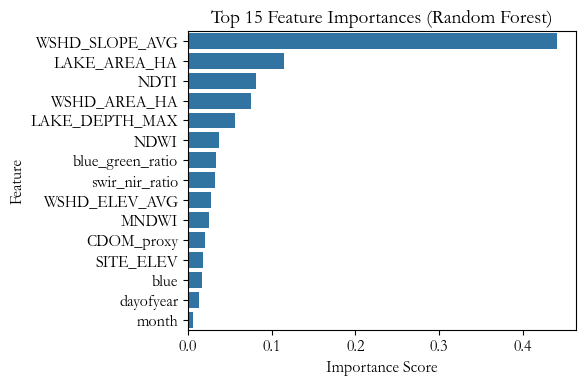

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# STEP 1: Prepare the data
# ---------------------------

# Make a copy to avoid modifying the original
df = altm_sr_processed.copy()

# Drop ID or descriptive columns not used in training
df = df.drop(columns=['SITE_ID', 'SITE_NAME', 'LATDD_CENTROID', 'LONDD_CENTROID'])
# 'blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'blue_green_ratio', 'NDWI', 'MNDWI', 'CDOM_proxy', 'NDTI', 'NDVI',

# Separate features and target
X = df.drop(columns=['DOC_MG_L'])
y = df['DOC_MG_L']

print("Feature order used for training/testing:")
print(list(X.columns))

# ---------------------------
# STEP 2: Train/Test Split
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# STEP 3: Train Random Forest
# ---------------------------

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# ---------------------------
# STEP 4: Evaluate Performance
# ---------------------------

y_pred = rf.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# ---------------------------
# STEP 5: Feature Importances
# ---------------------------

importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(6, 4))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


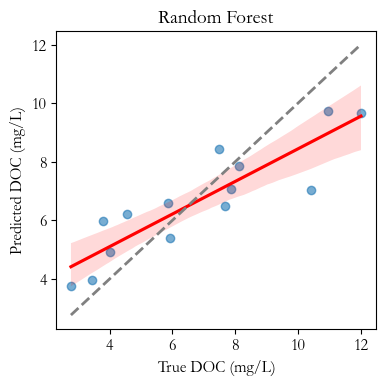

In [47]:
plt.figure(figsize=(4, 4))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='1:1 line', linewidth=2)
plt.xlabel("True DOC (mg/L)")
plt.ylabel("Predicted DOC (mg/L)")
plt.title("Random Forest")
plt.tight_layout()
plt.show()


Training models:   0%|                                                                           | 0/9 [00:00<?, ?it/s]

Random Forest - RMSE: 1.508, R²: 0.717


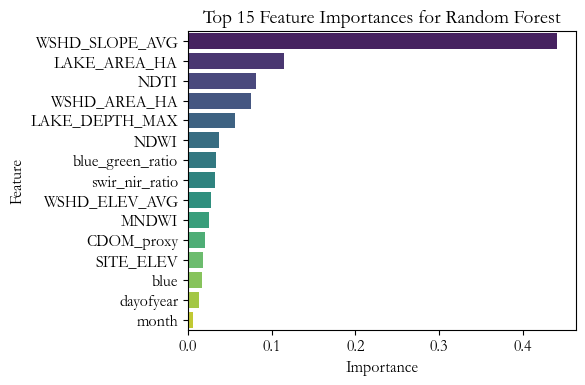

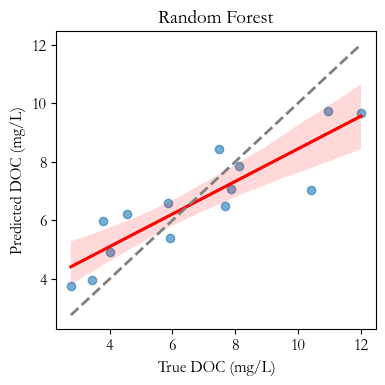

Training models:  11%|███████▍                                                           | 1/9 [00:01<00:14,  1.80s/it]

Gradient Boosting - RMSE: 1.636, R²: 0.667


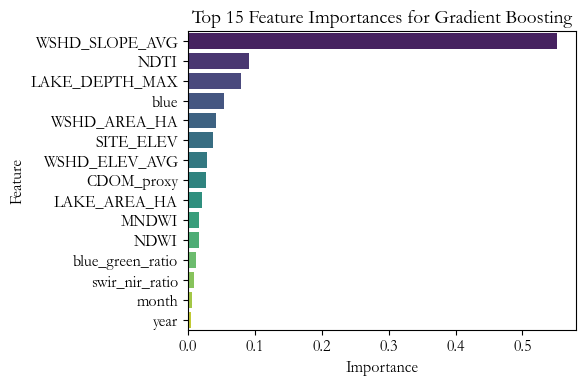

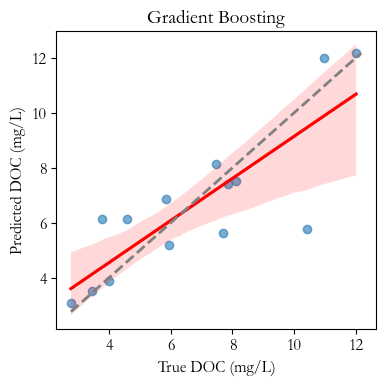

Training models:  22%|██████████████▉                                                    | 2/9 [00:02<00:10,  1.43s/it]

AdaBoost - RMSE: 1.280, R²: 0.796


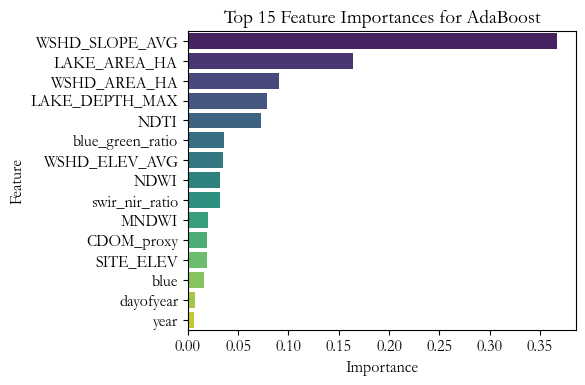

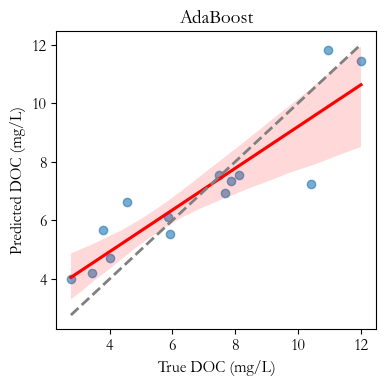

Training models:  33%|██████████████████████▎                                            | 3/9 [00:05<00:12,  2.14s/it]

Ridge - RMSE: 2.479, R²: 0.235


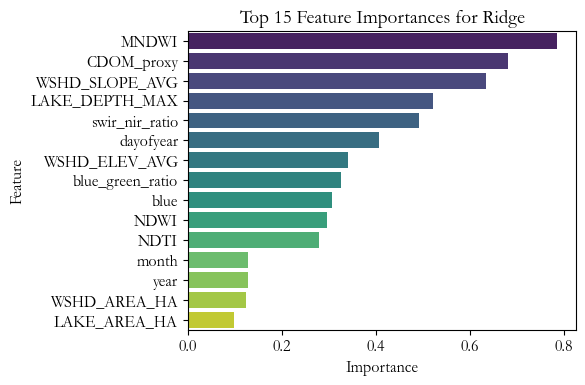

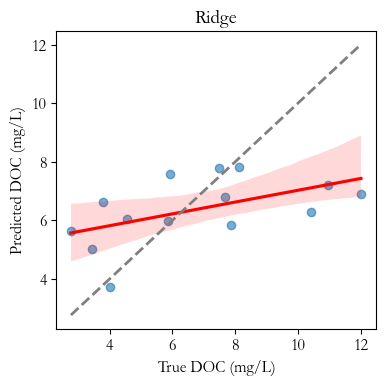

Training models:  44%|█████████████████████████████▊                                     | 4/9 [00:06<00:08,  1.66s/it]

Lasso - RMSE: 2.548, R²: 0.192


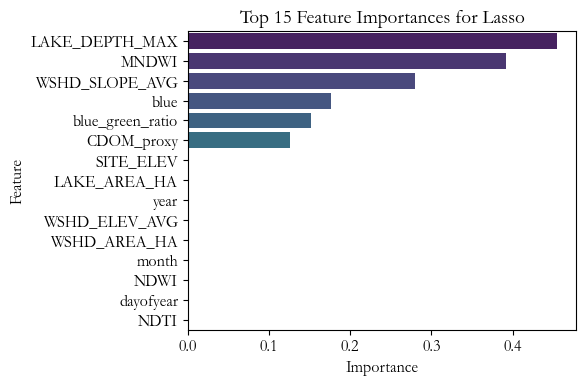

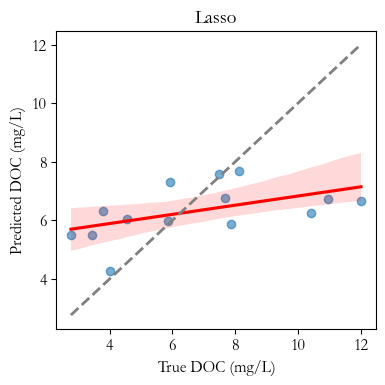

Training models:  56%|█████████████████████████████████████▏                             | 5/9 [00:07<00:05,  1.36s/it]

Decision Tree - RMSE: 1.516, R²: 0.714


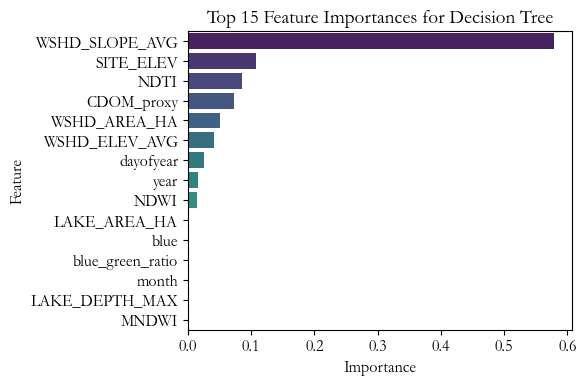

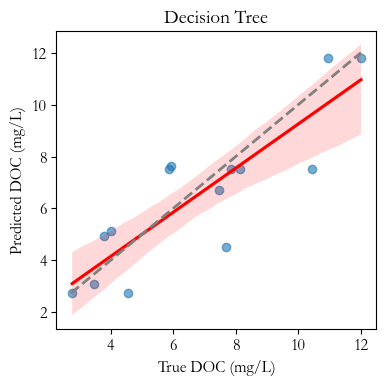

Training models:  67%|████████████████████████████████████████████▋                      | 6/9 [00:08<00:03,  1.21s/it]

SVR (RBF Kernel) - RMSE: 2.697, R²: 0.095


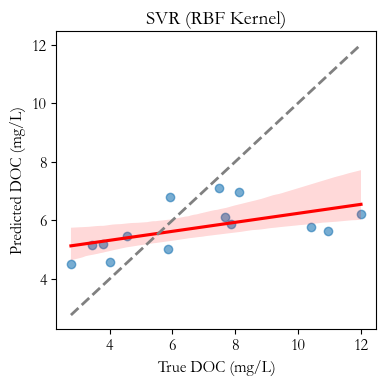

Training models:  78%|████████████████████████████████████████████████████               | 7/9 [00:08<00:01,  1.08it/s]

XGBoost - RMSE: 1.566, R²: 0.695


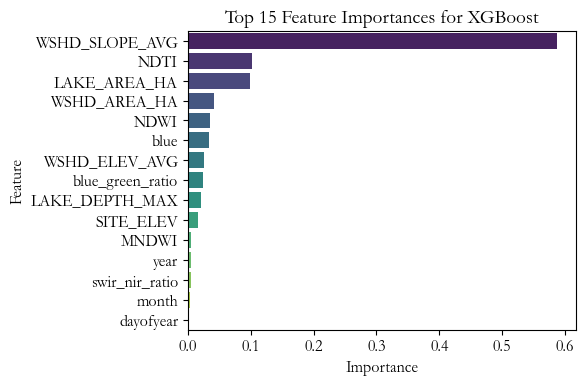

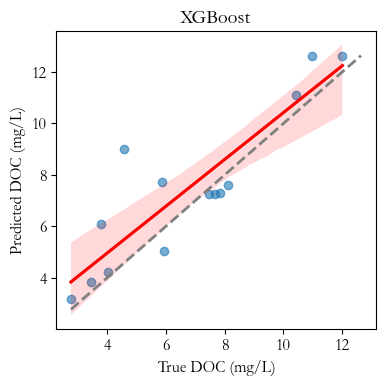

Training models:  89%|███████████████████████████████████████████████████████████▌       | 8/9 [00:11<00:01,  1.33s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000442 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 256
[LightGBM] [Info] Number of data points in the train set: 55, number of used features: 15
[LightGBM] [Info] Start training from score 6.005171
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

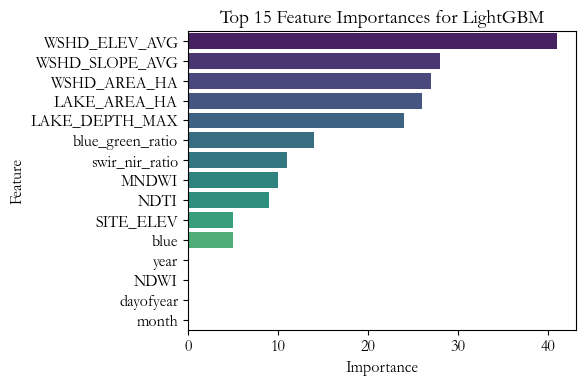

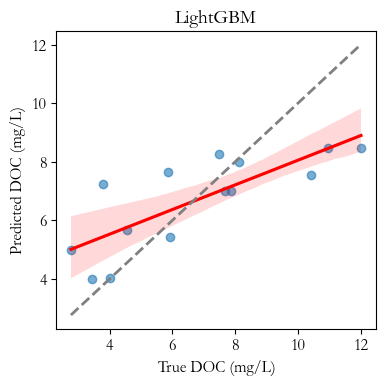

Training models: 100%|███████████████████████████████████████████████████████████████████| 9/9 [00:12<00:00,  1.36s/it]



Model Comparison:
               Model      RMSE        R2
2           AdaBoost  1.280351  0.795905
0      Random Forest  1.508411  0.716722
5      Decision Tree  1.515907  0.713900
7            XGBoost  1.566346  0.694544
1  Gradient Boosting  1.635771  0.666867
8           LightGBM  1.897545  0.551712
3              Ridge  2.479321  0.234688
4              Lasso  2.548056  0.191665
6   SVR (RBF Kernel)  2.696808  0.094531


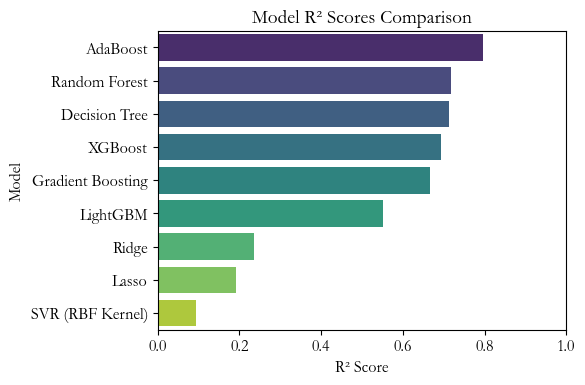

In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgb

# ---------------------------
# STEP 1: Prepare the data
# ---------------------------

df = altm_sr_processed.copy()

# Drop ID or descriptive columns not used in training
df = df.drop(columns=['SITE_ID', 'SITE_NAME', 'LATDD_CENTROID', 'LONDD_CENTROID'])

X = df.drop(columns=['DOC_MG_L'])
y = df['DOC_MG_L']

# Clean feature names (replace spaces with underscores)
X.columns = X.columns.str.replace(' ', '_')

# Convert boolean columns to integers (0/1)
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

# ---------------------------
# STEP 2: Train/Test Split
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# STEP 3: Define models
# ---------------------------

models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'SVR (RBF Kernel)': SVR(kernel='rbf', C=1.0, epsilon=0.2),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
}

# ---------------------------
# STEP 4: Train & Evaluate Models
# ---------------------------

results = []

for name in tqdm(models, desc="Training models"):
    model = models[name]
    model.fit(X_train, y_train)
    models[name] = model  # Save trained model back into the dictionary

    # import joblib

    # # Save only the AdaBoost model
    # if name == 'AdaBoost':
    #     joblib.dump(model, 'S2_adaboost_model_doc.pkl')

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # RMSE
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE': rmse, 'R2': r2})
    print(f"{name} - RMSE: {rmse:.3f}, R²: {r2:.3f}")

    # ---------------------------
    # Feature Importance Plot
    # ---------------------------
    
    # Some models have feature_importances_
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    # Linear models like Ridge and Lasso have coef_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_)
    else:
        importances = None

    if importances is not None:
        imp_df = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(15)
        plt.figure(figsize=(6, 4))
        sns.barplot(x=imp_df.values, y=imp_df.index, palette='viridis')
        plt.title(f"Top 15 Feature Importances for {name}")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

    # Scatterplot of True vs Predicted with regression line
    plt.figure(figsize=(4, 4))
    sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    min_val = min(min(y_test), min(y_pred))
    max_val = max(max(y_test), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='1:1 line', linewidth=2)
    plt.xlabel("True DOC (mg/L)")
    plt.ylabel("Predicted DOC (mg/L)")
    plt.title(f"{name}")
    plt.tight_layout()
    plt.show()

# ---------------------------
# STEP 5: Results Summary
# ---------------------------

results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print("\nModel Comparison:")
print(results_df)

# Optional: plot the R2 scores for comparison
plt.figure(figsize=(6, 4))
sns.barplot(x='R2', y='Model', data=results_df, palette='viridis')
plt.title("Model R² Scores Comparison")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


📉 Stacking Regressor RMSE: 1.772
📈 Stacking Regressor R²: 0.779


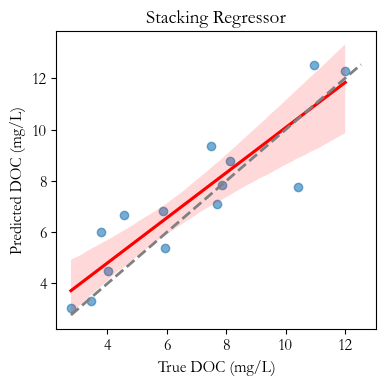

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# Prepare data
# ---------------------------

df = altm_sr_processed.copy()
df = df.drop(columns=['SITE_ID', 'SITE_NAME', 'LATDD_CENTROID', 'LONDD_CENTROID'])

X = df.drop(columns=['DOC_MG_L'])
y = df['DOC_MG_L']

X.columns = X.columns.str.replace(' ', '_')

for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Define top models
# ---------------------------

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

abr = AdaBoostRegressor(
    n_estimators=200, 
    learning_rate=0.1, 
    random_state=42)

# ---------------------------
# Stacking Regressor
# ---------------------------

estimators = [
    ('rf', rf),
    ('abr', abr)
]


stacking_regressor = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    n_jobs=-1
)

# Train stacking model
stacking_regressor.fit(X_train, y_train)
y_pred_stack = stacking_regressor.predict(X_test)
rmse_stack = mean_squared_error(y_test, y_pred_stack)
r2_stack = r2_score(y_test, y_pred_stack)

print(f"Stacking Regressor RMSE: {rmse_stack:.3f}")
print(f"Stacking Regressor R²: {r2_stack:.3f}")

# ---------------------------
# Scatterplot of True vs Predicted
# ---------------------------

plt.figure(figsize=(4, 4))
sns.regplot(x=y_test, y=y_pred_stack, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
min_val = min(min(y_test), min(y_pred_stack))
max_val = max(max(y_test), max(y_pred_stack))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='1:1 line', linewidth=2)
plt.xlabel("True DOC (mg/L)")
plt.ylabel("Predicted DOC (mg/L)")
plt.title("Stacking Regressor")
plt.tight_layout()
plt.show()

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 470ms/step - loss: 39.7761 - val_loss: 33.5970
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 38.0867 - val_loss: 31.8142
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 35.8954 - val_loss: 30.0790
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - loss: 33.5269 - val_loss: 28.1469
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - loss: 31.1459 - val_loss: 25.9673
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 29.7316 - val_loss: 23.6440
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 27.2706 - val_loss: 21.1563
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 23.6953 - val_loss: 18.5846
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 20.9473 - val_loss: 15.9600
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 18.9473 - val_loss: 13.3085
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 14.9713 - val_loss: 10.7329
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 

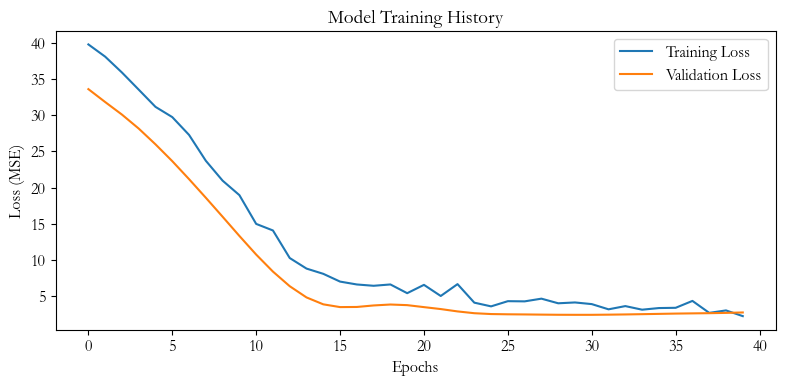

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------
# Prepare data
# ---------------------------

df = altm_sr_processed.copy()
df = df.drop(columns=['SITE_ID', 'SITE_NAME', 'LATDD_CENTROID', 'LONDD_CENTROID'])

X = df.drop(columns=['DOC_MG_L'])
y = df['DOC_MG_L']

# Clean feature names (just in case)
X.columns = X.columns.str.replace(' ', '_')

# Convert boolean columns to integers
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------
# Define Neural Network
# ---------------------------

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer for regression
])

model.compile(optimizer='adam', loss='mse')

# ---------------------------
# Train Model
# ---------------------------

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ---------------------------
# Evaluate Model
# ---------------------------

y_pred_nn = model.predict(X_test_scaled).flatten()
rmse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"Neural Network RMSE: {rmse_nn:.3f}")
print(f"Neural Network R2: {r2_nn:.3f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Training History")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.show()


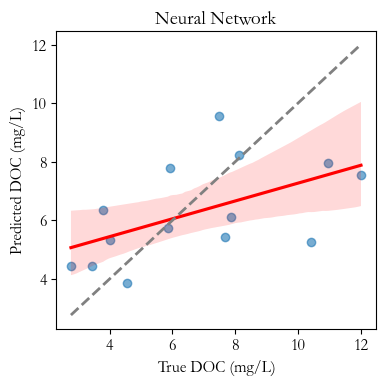

In [51]:
import seaborn as sns

plt.figure(figsize=(4, 4))
sns.regplot(x=y_test, y=y_pred_nn, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
min_val = min(min(y_test), min(y_pred_nn))
max_val = max(max(y_test), max(y_pred_nn))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', label='1:1 line', linewidth=2)
plt.xlabel("True DOC (mg/L)")
plt.ylabel("Predicted DOC (mg/L)")
plt.title("Neural Network")
plt.tight_layout()
plt.show()


In [52]:
# Identify the worst prediction
errors = np.abs(y_test - y_pred_nn)
worst_index = np.argmax(errors)

print(f"\nWorst prediction at index: {worst_index}")
print(f"True value: {y_test.iloc[worst_index]}")
print(f"Predicted: {y_pred_nn[worst_index]}")

# Optional: print input features for inspection
print("\nInput features for this sample:")
print(pd.Series(X_test.iloc[worst_index], index=X.columns))



Worst prediction at index: 1
True value: 10.4257135165466
Predicted: 5.259788513183594

Input features for this sample:
LAKE_DEPTH_MAX     -0.849122
LAKE_AREA_HA       -0.473546
WSHD_AREA_HA       -0.433112
SITE_ELEV          -0.577463
WSHD_ELEV_AVG      -0.655943
WSHD_SLOPE_AVG     -0.632903
blue               -0.401233
year                0.038097
month               0.214515
dayofyear           0.335421
blue_green_ratio    0.460809
NDWI               -0.322404
MNDWI              -0.569049
NDTI                0.345579
swir_nir_ratio      0.548865
CDOM_proxy          0.113196
Name: 51, dtype: float64


### Time-series (Using best model)

📊 Train RMSE: 0.349
📈 Train R²: 0.926
🧪 Test RMSE: 1.639
🧪 Test R²: 0.796


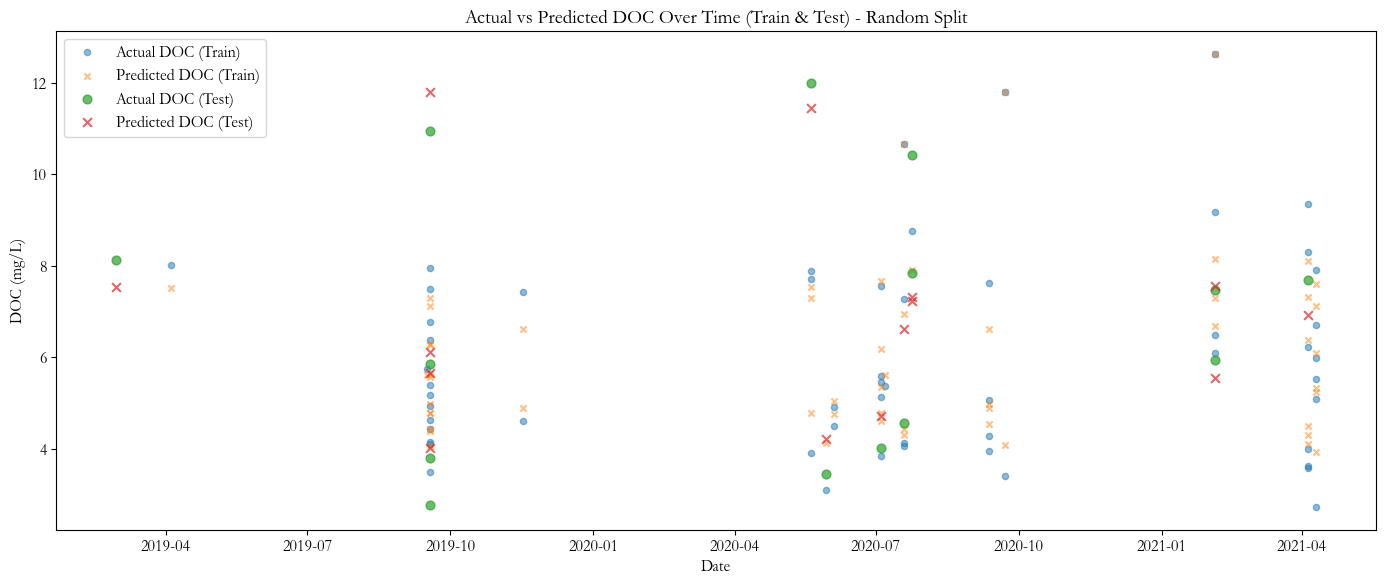

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb

# Prepare the data
df = altm_sr_processed.copy()
df['DATE_SMP'] = pd.to_datetime(altm_sr['DATE_SMP'])

# Define features and target
drop_cols = ['DOC_MG_L', 'SITE_ID', 'SITE_NAME', 'LATDD_CENTROID', 'LONDD_CENTROID', 'DATE_SMP']
X = df.drop(columns=drop_cols)
y = df['DOC_MG_L']

# Random split (not temporal)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Train LightGBM
model = AdaBoostRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Get corresponding dates for plotting
train_dates = df.loc[y_train.index, 'DATE_SMP']
test_dates = df.loc[y_test.index, 'DATE_SMP']

# Metrics
rmse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

rmse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Train RMSE: {rmse_train:.3f}")
print(f"Train R²: {r2_train:.3f}")
print(f"Test RMSE: {rmse_test:.3f}")
print(f"Test R²: {r2_test:.3f}")

# Scatterplot over time
plt.figure(figsize=(14, 6))

plt.scatter(train_dates, y_train, label='Actual DOC (Train)', alpha=0.5, s=20)
plt.scatter(train_dates, y_train_pred, label='Predicted DOC (Train)', alpha=0.5, s=20, marker='x')

plt.scatter(test_dates, y_test, label='Actual DOC (Test)', alpha=0.7, s=40)
plt.scatter(test_dates, y_test_pred, label='Predicted DOC (Test)', alpha=0.7, s=40, marker='x')

plt.xlabel('Date')
plt.ylabel('DOC (mg/L)')
plt.title('Actual vs Predicted DOC Over Time (Train & Test) - Random Split')
plt.legend()
plt.tight_layout()
plt.show()
